In [4]:
import tensorflow as tf
import os
import matplotlib.pyplot as plt

base_dir = '/Users/rohitkr/Downloads/Vegetable Images'

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

# parameters 
BATCH_SIZE = 32
IMG_SIZE = (224, 224)


In [5]:
import warnings
import os
warnings.filterwarnings('ignore')


In [7]:
print("Loading Training Data...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

print("\n Loading Validation Data...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    shuffle=False, # No need to shuffle validation data
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

print("\n Loading Testing Data...")
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=False,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

#class names
class_names = train_ds.class_names
print(f"\nFound {len(class_names)} classes: {class_names}")

Loading Training Data...
Found 15000 files belonging to 15 classes.

 Loading Validation Data...
Found 3000 files belonging to 15 classes.

 Loading Testing Data...
Found 3000 files belonging to 15 classes.

Found 15 classes: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']


In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Optimizing Data Pipeline.....")

Optimizing Data Pipeline.....


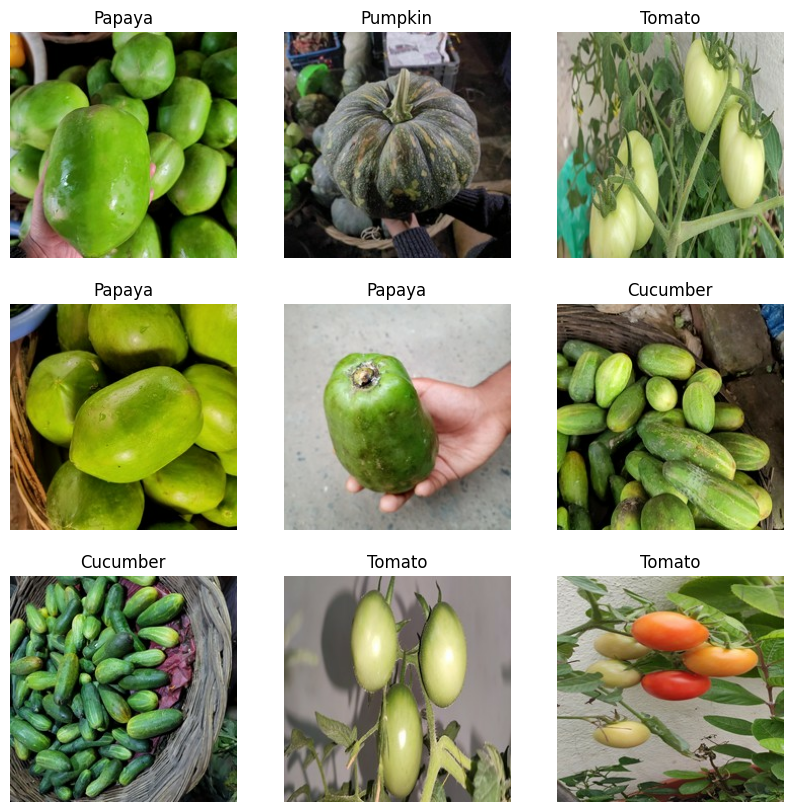

2026-04-08 14:01:40.033050: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [9]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        # We have to reverse the one-hot encoding to get the class name
        label_index = tf.argmax(labels[i]).numpy()
        plt.title(class_names[label_index])
        plt.axis("off")
    plt.show()

In [10]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetV2B0
import tensorflow as tf

In [11]:
def build_transfer_model(num_classes):
    # Pre-trained model (EfficientNetV2B0)
    base_model = EfficientNetV2B0(
        weights='imagenet', 
        include_top=False, 
        input_shape=(224, 224, 3)
    )
    
    # model=false, to protect pre-trained weights
    base_model.trainable = False 
    
    # new model
    inputs = layers.Input(shape=(224, 224, 3))
    
    # training=False to keep BatchNormalization layers
    x = base_model(inputs, training=False) 
    
    # custom classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x) 
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    return model, base_model

transfer_model, base_model = build_transfer_model(len(class_names))

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

transfer_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,943,647 (22.67 MB)

 Trainable params: 21,775 (85.06 KB)

 Non-trainable params: 5,921,872 (22.59 MB)

In [12]:
# checkpoint for saving best model 
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'efficientnet_vegetables_best.keras', 
    monitor='val_accuracy', 
    save_best_only=True,
    mode='max',
    verbose=1
)

# early stop 
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=2, 
    min_lr=1e-6,
    verbose=1
)

In [13]:
print("Training the custom head.....")

EPOCHS = 15

history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

print("Training Complete")

Training the custom head.....
Epoch 1/15


2026-04-08 14:01:58.677713: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.8170 - loss: 0.6435
Epoch 1: val_accuracy improved from None to 0.99733, saving model to efficientnet_vegetables_best.keras

Epoch 1: finished saving model to efficientnet_vegetables_best.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 56s 108ms/step - accuracy: 0.9324 - loss: 0.2329 - val_accuracy: 0.9973 - val_loss: 0.0143 - learning_rate: 0.0010
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.9923 - loss: 0.0318
Epoch 2: val_accuracy improved from 0.99733 to 0.99833, saving model to efficientnet_vegetables_best.keras

Epoch 2: finished saving model to efficientnet_vegetables_best.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 152ms/step - accuracy: 0.9928 - loss: 0.0283 - val_accuracy: 0.9983 - val_loss: 0.0061 - learning_rate: 0.0010
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9962 - loss: 0.0150
Epoch 3: val_accuracy improved from 0.99833 to 0.99900, saving model to efficientnet_vegetables_best.keras

E

94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.9997 - loss: 0.0044

Final Test Accuracy: 99.97%


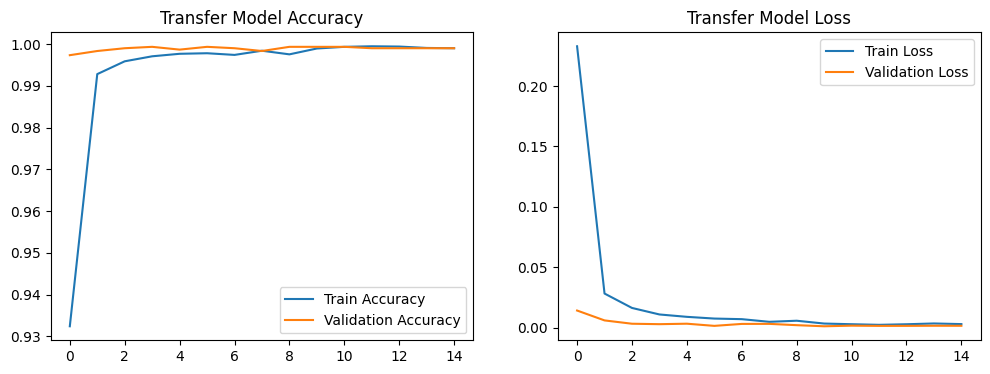

In [15]:
import matplotlib.pyplot as plt

# running test dataset
test_loss, test_acc = transfer_model.evaluate(test_ds)
print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

# viz
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Transfer Model Loss')
plt.legend()

plt.show()

In [16]:
print("Fine-tuning the model....")

# using base model first
base_model.trainable = True

# using bottom layers
for layer in base_model.layers[:-30]: # fine-tuning top 30 layers 
    layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

# 4. Check how many layers are actually trainable now
trainable_count = sum([1 for layer in transfer_model.trainable_weights])
print(f"Number of trainable weights after unfreezing: {trainable_count}")

#resuming from phase 1
phase_2_epochs = 10
total_epochs = EPOCHS + phase_2_epochs

history_fine = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1], # resume from end of phase 1
    callbacks=[checkpoint, early_stop, reduce_lr]
)

print("Model Training Complete ")

Fine-tuning the model....
Number of trainable weights after unfreezing: 30
Epoch 15/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.9926 - loss: 0.0213
Epoch 15: val_accuracy did not improve from 0.99933
469/469 ━━━━━━━━━━━━━━━━━━━━ 113s 222ms/step - accuracy: 0.9933 - loss: 0.0214 - val_accuracy: 0.9990 - val_loss: 0.0025 - learning_rate: 1.0000e-05
Epoch 16/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9951 - loss: 0.0158
Epoch 16: val_accuracy did not improve from 0.99933

Epoch 16: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
469/469 ━━━━━━━━━━━━━━━━━━━━ 92s 197ms/step - accuracy: 0.9957 - loss: 0.0141 - val_accuracy: 0.9987 - val_loss: 0.0026 - learning_rate: 1.0000e-05
Epoch 17/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9972 - loss: 0.0102
Epoch 17: val_accuracy did not improve from 0.99933
469/469 ━━━━━━━━━━━━━━━━━━━━ 92s 197ms/step - accuracy: 0.9968 - loss: 0.0108 - val_accuracy: 0.9990 - val_loss: 0.0025 - lear

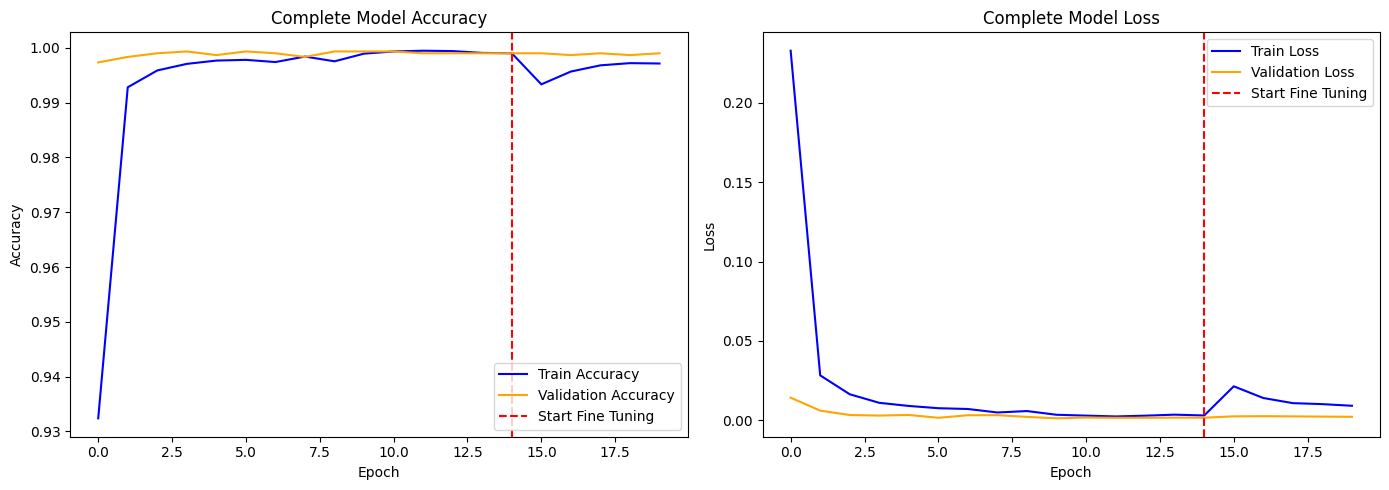

In [17]:
# combining both phases(actual+fine tuned)
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

# subtract 1 because epochs are 0-indexed in the graph
initial_epochs = len(history.history['accuracy']) - 1 

plt.figure(figsize=(14, 5)) # Slightly wider to accommodate the full timeline

# Accuracy Subplot
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy', color='blue')
plt.plot(val_acc, label='Validation Accuracy', color='orange')
# Add a vertical dashed line to mark the start of Fine-Tuning
plt.axvline(x=initial_epochs, color='red', linestyle='--', label='Start Fine Tuning')
plt.title('Complete Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss Subplot 
plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')

plt.axvline(x=initial_epochs, color='red', linestyle='--', label='Start Fine Tuning')
plt.title('Complete Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [1]:
# for real-time sim
import cv2
import numpy as np
import tensorflow as tf
import time

In [20]:
import cv2
import numpy as np
import tensorflow as tf
import time
from collections import deque, Counter

print("Loading model... (this takes a few seconds)")
model = tf.keras.models.load_model('efficientnet_vegetables_best.keras')

class_names = [
    'Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 
    'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 
    'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato' 
]

cap = cv2.VideoCapture(0)
IMG_SIZE = 224

# using buffer size so that model doesnt spam 
BUFFER_SIZE = 45 
prediction_buffer = deque(maxlen=BUFFER_SIZE)
last_locked_target = None

print("Model Predicting....! Press 'q' to quit.")

while True:
    start_time = time.time()
    ret, frame = cap.read()
    if not ret: break
        
    frame = cv2.flip(frame, 1)
    height, width, _ = frame.shape
    
    box_size = 350
    start_x = (width - box_size) // 2
    start_y = (height - box_size) // 2
    end_x = start_x + box_size
    end_y = start_y + box_size

    roi = frame[start_y:end_y, start_x:end_x]
    
    img_array = cv2.resize(roi, (IMG_SIZE, IMG_SIZE))
    img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array.astype('float32') 
    
    predictions = model.predict(img_array, verbose=0)
    score = predictions[0] 
    
    confidence = np.max(score) * 100
    predicted_class = class_names[np.argmax(score)]
    
    if confidence > 60.0:
        prediction_buffer.append(predicted_class)
    else:
        prediction_buffer.clear()
        last_locked_target = None

    # making the model vote for the veggie (highest votes = vegetable predicted)
    if len(prediction_buffer) == BUFFER_SIZE:
        vote_counts = Counter(prediction_buffer)
        winner, winner_votes = vote_counts.most_common(1)[0]
        
        if winner_votes >= int(BUFFER_SIZE * 0.8):
            box_color = (0, 255, 0) # GREEN: Locked and Confirmed
            thickness = 4
            label = f"{winner} (Verified)"
            
            cv2.rectangle(frame, (start_x, start_y), (end_x, end_y), box_color, thickness)
            (text_w, text_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_DUPLEX, 0.8, 2)
            cv2.rectangle(frame, (start_x, start_y - 35), (start_x + text_w + 10, start_y), box_color, -1)
            cv2.putText(frame, label, (start_x + 5, start_y - 10), cv2.FONT_HERSHEY_DUPLEX, 0.8, (0, 0, 0), 2)
            
            if winner != last_locked_target:
                print(f" Target: {winner} (Based on {winner_votes}/{BUFFER_SIZE} frames)")
                last_locked_target = winner
                
        else:
            box_color = (0, 165, 255) 
            cv2.rectangle(frame, (start_x, start_y), (end_x, end_y), box_color, 3)
            cv2.putText(frame, "Stabilizing...", (start_x, start_y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, box_color, 2)

    elif len(prediction_buffer) > 0:
        box_color = (0, 255, 255) # analyzing box
        progress = int((len(prediction_buffer) / BUFFER_SIZE) * 100)
        
        cv2.rectangle(frame, (start_x, start_y), (end_x, end_y), box_color, 2)
        cv2.putText(frame, f"Analyzing... {progress}%", (start_x, start_y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, box_color, 2)
        
    else:
        box_color = (255, 200, 0) # scanning box
        cv2.rectangle(frame, (start_x, start_y), (end_x, end_y), box_color, 2)
        cv2.putText(frame, "Scanning...", (start_x, start_y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, box_color, 2)

    fps = 1.0 / (time.time() - start_time)
    cv2.putText(frame, f"FPS: {fps:.1f}", (15, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    
    cv2.imshow('Vegetable Detector', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Loading model... (this takes a few seconds)
Model Predicting....! Press 'q' to quit.
 Target: Potato (Based on 45/45 frames)
 Target: Tomato (Based on 38/45 frames)
 Target: Capsicum (Based on 44/45 frames)
 Target: Carrot (Based on 43/45 frames)
 Target: Bottle_Gourd (Based on 45/45 frames)
 Target: Bottle_Gourd (Based on 45/45 frames)
 Target: Bottle_Gourd (Based on 43/45 frames)
 Target: Bottle_Gourd (Based on 45/45 frames)
